In [1]:
import numpy as np

from mgwr.gwr import GWR as OfficialGWR
from mgwr.sel_bw import Sel_BW

from src.log.gwr_logger import GwrLogger
from src.kernel.gwr_kernel import GwrKernel
from src.model.gwr import GWR
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset

Create the simulated dataset

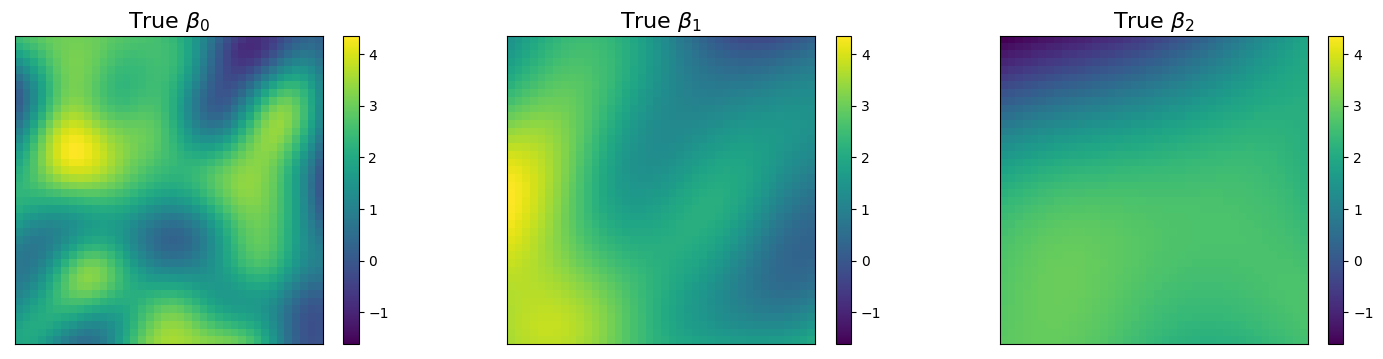

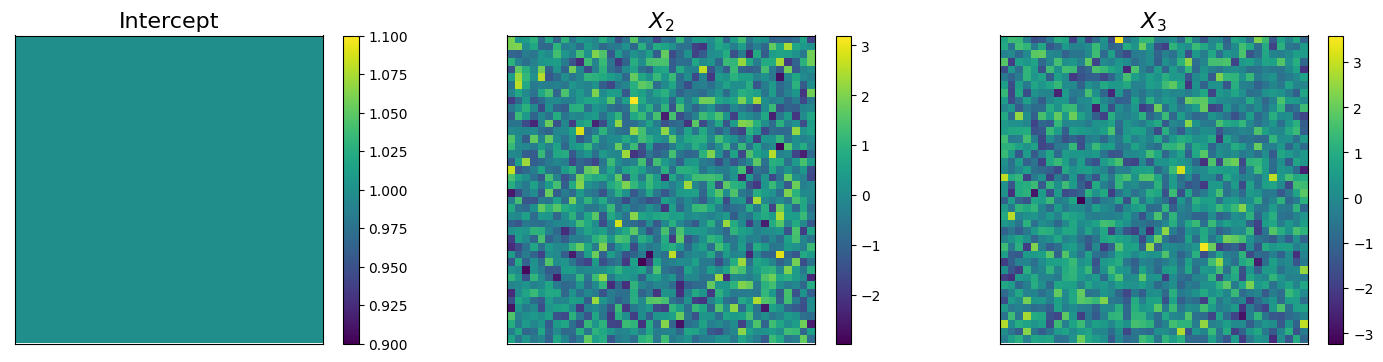

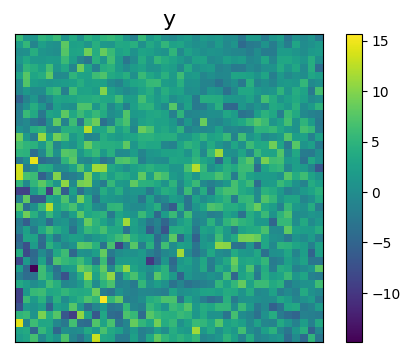

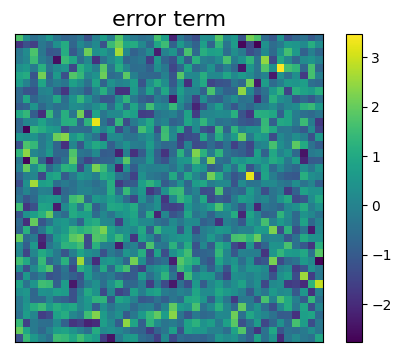

In [10]:
k = 2
field_size = 40
dataset = SimulatedSpatialDataset(
    k=k,
    field_size=field_size
)
[X] = dataset.generate_data()
[beta] = dataset.generate_processes()
[y, err] = dataset.fit_y(X, beta)

dataset.plot(
    b=beta.T,
    sub_title=[r"True $\beta_0$", r"True $\beta_1$", r"True $\beta_2$"],
    size=field_size,
    vmin=beta.min(),
    vmax=beta.max()
)

dataset.plot(
    b=X.T,
    sub_title=[r"Intercept", r"$X_2$", r"$X_3$"],
    size=field_size
)

dataset.plot(
    b=y.reshape(1, -1),
    sub_title=['y'],
    size=field_size
)

dataset.plot(
    b=err.reshape(1, -1),
    sub_title=['error term'],
    size=field_size
)


Create the GWR model (lmgwr codebase)

In [4]:
manual_bandwidth = 70 # which is also the optimal bandwidth found by golden-section search

# Create a GWR kernel and GWR model.
kernel = GwrKernel(dataset, 'bisquare')
refactored_gwr = GWR(dataset, kernel)

Create the GWR model (Official MGWR codebase)

In [5]:
g_X = dataset.X[:, 1:]
g_y = dataset.y.reshape(-1, 1)
g_coords = dataset.coordinates.tolist()


# gwr_selector = Sel_BW(g_coords, g_y, g_X)
# gwr_bw = gwr_selector.search(bw_min=2)
# print(gwr_bw)
# official_gwr = OfficialGWR(g_coords, g_y, g_X, gwr_bw).fit()


official_gwr = OfficialGWR(g_coords, g_y, g_X, manual_bandwidth, hat_matrix=True)

Fit both models with the same bandwidth

In [6]:
refactored_gwr.update_bandwidth(manual_bandwidth).fit()
official_gwr_result = official_gwr.fit()

Compare outputs

In [7]:
s_matrix_match = np.allclose(refactored_gwr.S, official_gwr_result.S)
betas_match = np.allclose(refactored_gwr.betas, official_gwr_result.params)

print("="*60)
print("GWR Model Comparison")
print("="*60)
print(f"{'Metric':30} {'Custom GWR':>12} {'Official GWR':>15}")
print("-"*60)
print(f"{'R-squared':30} {refactored_gwr.r_squared:12.4f} {official_gwr_result.R2:15.4f}")
print(f"{'AIC':30} {refactored_gwr.aic:12.2f} {official_gwr_result.aic:15.2f}")
print(f"{'AICc':30} {refactored_gwr.aicc:12.2f} {official_gwr_result.aicc:15.2f}")
print("-"*60)
print(f"{'Coefficient matrices match?':30} {str(betas_match):>12}")
print(f"{'S matrices match?':30} {str(s_matrix_match):>12}")
print("="*60)


GWR Model Comparison
Metric                           Custom GWR    Official GWR
------------------------------------------------------------
R-squared                            0.9273          0.9273
AIC                                 4683.63         4683.63
AICc                                4727.94         4727.94
------------------------------------------------------------
Coefficient matrices match?            True
S matrices match?                      True


Plot the parameter estimates

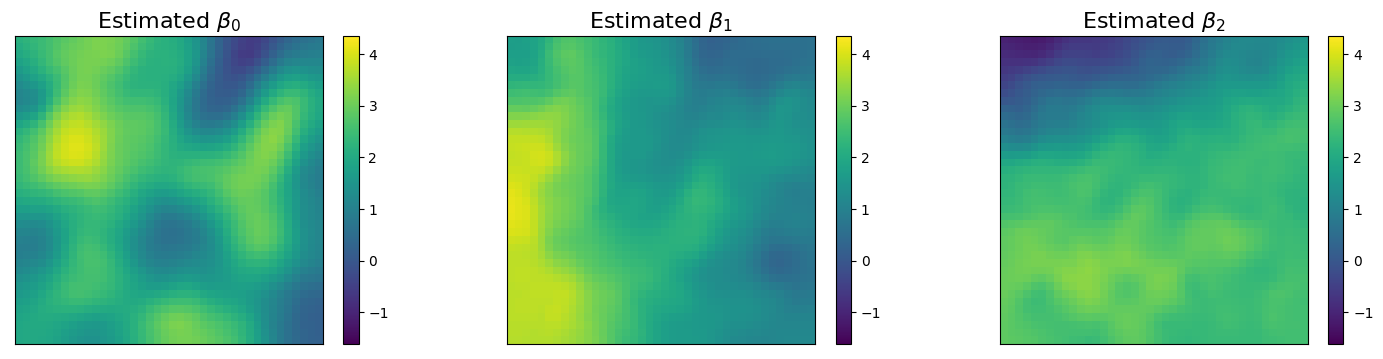

In [12]:
dataset.plot(
    b=refactored_gwr.betas.T,
    sub_title=[r"Estimated $\beta_0$", r"Estimated $\beta_1$", r"Estimated $\beta_2$"],
    size=field_size,
    vmin=beta.min(),
    vmax=beta.max()
)